In [1]:
import sys
sys.path.insert(0, ".")
import matplotlib.pyplot as plt
import numpy as np
from datasets import load_dataset
from tqdm.notebook import tqdm

In [2]:
# Cell — Load without trust_remote_code
ds = load_dataset(
    "friedrichor/ActivityNet_Captions",
    split="train",
    streaming=True,
)

sample = next(iter(ds))
print(sample.keys())

dict_keys(['video_id', 'video', 'caption', 'source', 'duration', 'timestamps', 'sentences'])


In [3]:
samples = []
for i, sample in enumerate(ds):
    samples.append({
        "video_id"  : sample["video_id"],
        "duration"  : sample["duration"],
        "timestamps": sample["timestamps"],
        "sentences" : sample["sentences"],   # ← was "sentence"
        "caption"   : sample["caption"],     # ← bonus: full video caption
    })
    if i >= 2:
        break

import json
for s in samples:
    print(json.dumps(s, indent=2))
    print("─" * 60)

{
  "video_id": "v_QOlSCBRmfWY",
  "duration": 82.73,
  "timestamps": [
    [
      0.83,
      19.86
    ],
    [
      17.37,
      60.81
    ],
    [
      56.26,
      79.42
    ]
  ],
  "sentences": [
    "A young woman is seen standing in a room and leads into her dancing.",
    "The girl dances around the room while the camera captures her movements.",
    "She continues dancing around the room and ends by laying on the floor."
  ],
  "caption": "A young woman is seen standing in a room and leads into her dancing. The girl dances around the room while the camera captures her movements. She continues dancing around the room and ends by laying on the floor."
}
────────────────────────────────────────────────────────────
{
  "video_id": "v_ehGHCYKzyZ8",
  "duration": 61.72,
  "timestamps": [
    [
      0.0,
      2.78
    ],
    [
      3.09,
      61.72
    ],
    [
      15.43,
      55.24
    ],
    [
      17.59,
      54.0
    ],
    [
      39.81,
      54.62
    ],
    [
  

In [4]:
segment_durations = []
segments_per_video = []
video_durations = []

for i, sample in enumerate(tqdm(ds, total=500)):
    ts = sample["timestamps"]
    segments_per_video.append(len(ts))
    video_durations.append(sample["duration"])
    for t in ts:
        segment_durations.append(t[1] - t[0])
    if i >= 499:
        break

print(f"Videos analyzed       : {len(segments_per_video)}")
print(f"Total segments        : {len(segment_durations)}")
print()
print(f"Segments per video    : avg={np.mean(segments_per_video):.1f}  min={np.min(segments_per_video)}  max={np.max(segments_per_video)}")
print(f"Segment duration (s)  : avg={np.mean(segment_durations):.1f}  min={np.min(segment_durations):.1f}  max={np.max(segment_durations):.1f}")
print(f"Video duration (s)    : avg={np.mean(video_durations):.1f}  min={np.min(video_durations):.1f}  max={np.max(video_durations):.1f}")

  0%|          | 0/500 [00:00<?, ?it/s]

Videos analyzed       : 500
Total segments        : 1873

Segments per video    : avg=3.7  min=2  max=17
Segment duration (s)  : avg=35.5  min=0.1  max=292.6
Video duration (s)    : avg=116.2  min=4.4  max=536.9


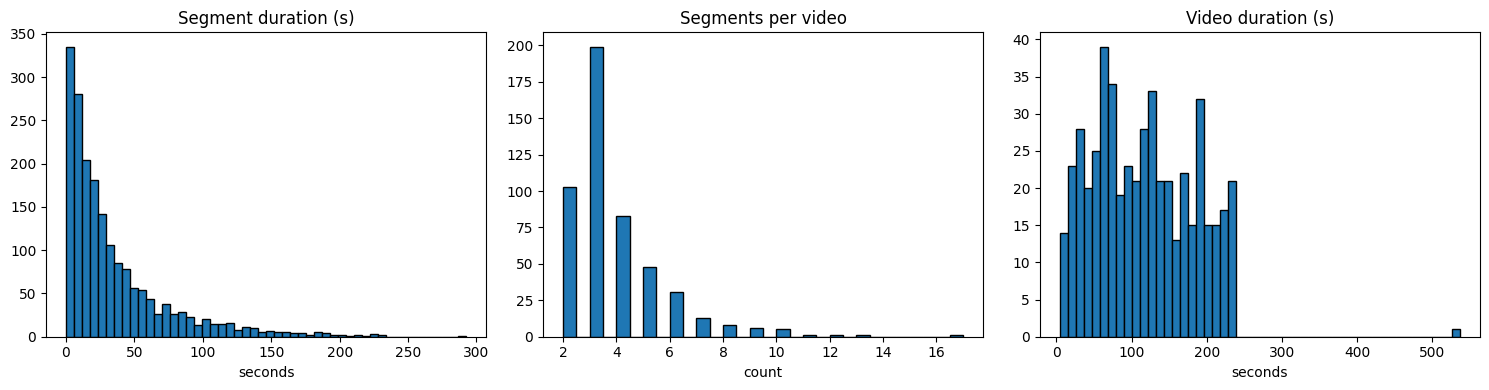

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(segment_durations, bins=50, edgecolor="black")
axes[0].set_title("Segment duration (s)")
axes[0].set_xlabel("seconds")

axes[1].hist(segments_per_video, bins=30, edgecolor="black")
axes[1].set_title("Segments per video")
axes[1].set_xlabel("count")

axes[2].hist(video_durations, bins=50, edgecolor="black")
axes[2].set_title("Video duration (s)")
axes[2].set_xlabel("seconds")

plt.tight_layout()
plt.show()

In [6]:
# Timestamps that go backwards or overlap heavily
overlapping = 0
backwards   = 0
very_short  = 0  # under 1 second

for i, sample in enumerate(tqdm(ds, total=500)):
    ts = sample["timestamps"]
    for j, t in enumerate(ts):
        if t[1] < t[0]:
            backwards += 1
        if (t[1] - t[0]) < 1.0:
            very_short += 1
        if j > 0:
            prev_end = ts[j-1][1]
            if t[0] < prev_end:
                overlapping += 1
    if i >= 499:
        break

print(f"Backwards timestamps  : {backwards}")
print(f"Very short (<1s)      : {very_short}")
print(f"Overlapping segments  : {overlapping}")

  0%|          | 0/500 [00:00<?, ?it/s]

Backwards timestamps  : 0
Very short (<1s)      : 16
Overlapping segments  : 432


In [7]:
# Verify frame count logic for different segment lengths
from src.frame_extractor import FrameExtractor, ExtractionConfig

config = ExtractionConfig(frames_per_segment=8, max_frames_per_segment=16)
extractor = FrameExtractor(config)

for duration in [5, 35, 60, 120, 292]:
    times = extractor._sample_frame_times(0, duration)
    print(f"{duration:4d}s segment → {len(times):2d} frames  (every {duration/len(times):.1f}s)")

   5s segment →  1 frames  (every 5.0s)
  35s segment →  8 frames  (every 4.4s)
  60s segment →  8 frames  (every 7.5s)
 120s segment →  8 frames  (every 15.0s)
 292s segment →  8 frames  (every 36.5s)


objc[45909]: Class AVFFrameReceiver is implemented in both /Users/jasmineguan/miniforge3/envs/video_caption/lib/python3.12/site-packages/av/.dylibs/libavdevice.62.1.100.dylib (0x1787403a8) and /Users/jasmineguan/miniforge3/envs/video_caption/lib/python3.12/site-packages/cv2/.dylibs/libavdevice.61.3.100.dylib (0x3572583a8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[45909]: Class AVFAudioReceiver is implemented in both /Users/jasmineguan/miniforge3/envs/video_caption/lib/python3.12/site-packages/av/.dylibs/libavdevice.62.1.100.dylib (0x1787403f8) and /Users/jasmineguan/miniforge3/envs/video_caption/lib/python3.12/site-packages/cv2/.dylibs/libavdevice.61.3.100.dylib (0x3572583f8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
